## Testing microsoft/git-base

In [1]:
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Load an image
image_path = 'Albums/Birthday/3033433439.jpg'  # Change this to your image path
image = Image.open(image_path).convert("RGB")

# Process image
inputs = processor(images=image, return_tensors="pt")

# Generate text
with torch.no_grad():
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Output the generated caption
print("Generated Text:", generated_text)

c:\Users\Matthew\miniconda3\envs\pytdml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the last token (EOS token) of the input_ids and attention_mask tensors will be removed. To test the new behavior, set `legacy=False`as a processor call argument.


Generated Text: the white building in the background is the national bank building.


## Testing BLIP1

In [2]:
from transformers import BlipTextConfig, BlipTextModel

# Initializing a BlipTextConfig with Salesforce/blip-vqa-base style configuration
configuration = BlipTextConfig()

# Initializing a BlipTextModel (with random weights) from the Salesforce/blip-vqa-base style configuration
model = BlipTextModel(configuration)

# Accessing the model configuration
configuration = model.config

In [3]:
from PIL import Image
import requests
from transformers import AutoProcessor, BlipModel

model = BlipModel.from_pretrained("Salesforce/blip-image-captioning-base")
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(
    text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.
Some weights of BlipModel were not initialized from the model checkpoint at Salesforce/blip-image-captioning-base and are newly initialized: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight', 'text_model.encoder.layer.0.attention.self.key.bias', 'text_model.encoder.layer.0.attention.self.key.weight', 'text_model.encoder.layer.0.attention.self.query.bias', 'text_model.encoder.layer.0.attention.self.query.weight', 'text_mo

## Optimal Size

Best resizing dimensions: 500x375


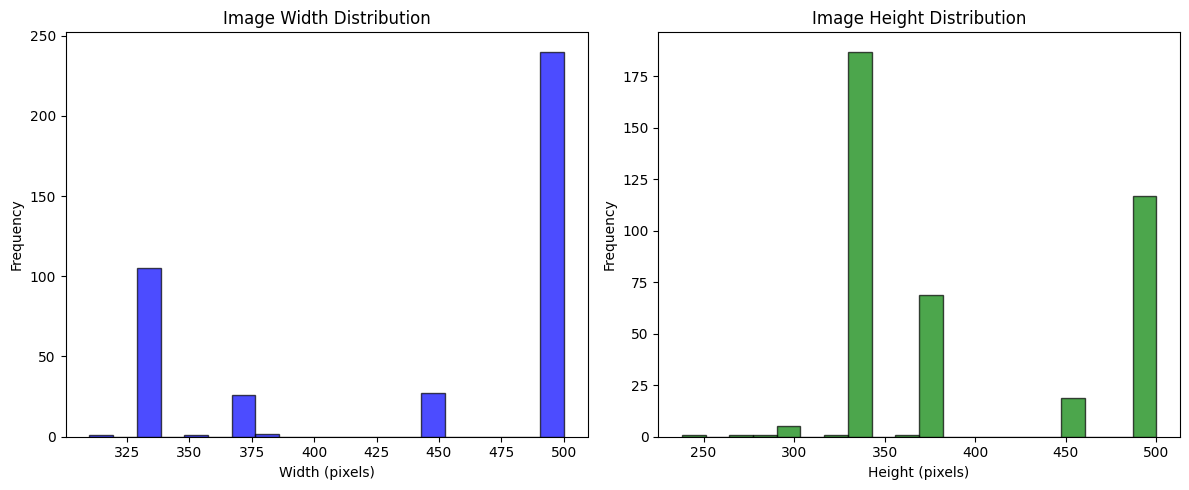

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

def analyze_image_sizes(root_folder):
    """
    Analyzes all images in the given folder and determines the best resizing size
    based on the median dimensions of all images.

    Parameters:
        root_folder (str): The path to the root folder containing images.

    Returns:
        tuple: (best_width, best_height)
    """
    widths = []
    heights = []
    
    # Scan all subfolders
    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        widths.append(width)
                        heights.append(height)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    if not widths or not heights:
        print("No images found!")
        return None

    # Compute the best resizing size (median dimensions)
    best_width = int(np.median(widths))
    best_height = int(np.median(heights))

    print(f"Best resizing dimensions: {best_width}x{best_height}")

    # Visualize the distribution of image sizes
    visualize_image_sizes(widths, heights)

    return best_width, best_height


def visualize_image_sizes(widths, heights):
    """
    Creates histograms for image widths and heights to visualize size distribution.

    Parameters:
        widths (list): List of image widths.
        heights (list): List of image heights.
    """
    plt.figure(figsize=(12, 5))

    # Plot Widths
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=20, color="blue", alpha=0.7, edgecolor="black")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Width Distribution")

    # Plot Heights
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=20, color="green", alpha=0.7, edgecolor="black")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Height Distribution")

    plt.tight_layout()
    plt.show()


# Example usage
root_folder = "./Albums"  # Change this to your dataset path
best_size = analyze_image_sizes(root_folder)


## Testing K-MEANS

Loading images...
Clustering with K-Means...
Clustering accuracy: 44.28%
Clusters saved to clusters.txt


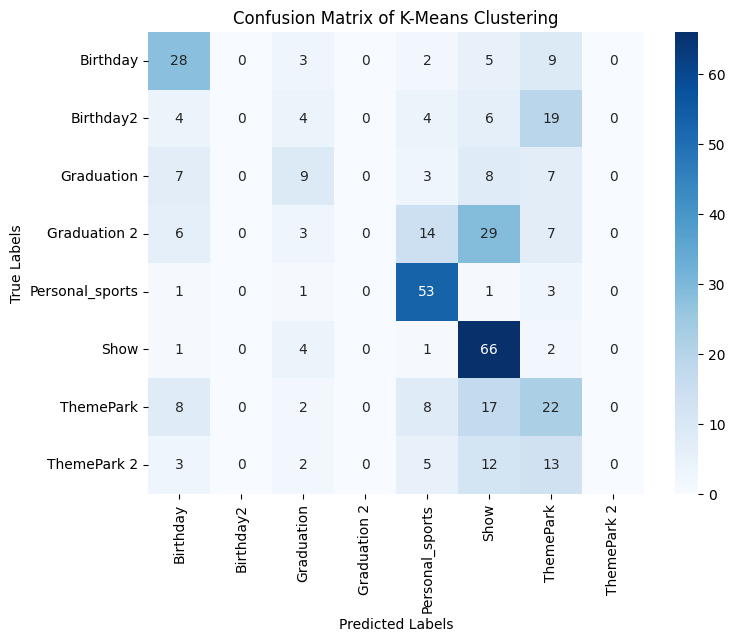

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Function to load images from subfolders and preprocess them
def load_images_from_folder(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        img = img.convert("L")  # Convert to grayscale for consistency ---------------------
                        img = img.resize(image_size)  # Resize to a fixed size
                        image_data.append(np.array(img).flatten())  # Flatten pixel values
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names

# Function to perform clustering and evaluate accuracy
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    """
    Performs K-Means clustering on images and evaluates accuracy.

    Parameters:
        root_folder (str): Path to dataset root folder.
        image_size (tuple): Size to which images are resized.
        save_txt (bool): Whether to save cluster assignments in a text file.

    Returns:
        tuple: (K-Means model, accuracy score)
    """
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder(root_folder, image_size)

    print("Clustering with K-Means...")
    kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    for cluster in range(len(label_names)):
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
        if len(true_labels_in_cluster) > 0:
            # Assign cluster to the most frequent true label in it
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

    # Calculate clustering accuracy
    accuracy = accuracy_score(y_true, y_pred_mapped)
    print(f"Clustering accuracy: {accuracy:.2%}")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true]})\n")
        print("Clusters saved to clusters.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true, y_pred_mapped, label_names)

    return kmeans, accuracy


# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    """
    Plots a confusion matrix to show clustering performance.

    Parameters:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted cluster labels.
        label_names (list): List of label names.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of K-Means Clustering")
    plt.show()


# Example usage
root_folder = "./Albums"
kmeans_model, acc = cluster_images(root_folder, image_size=(500 , 375), save_txt=True)


## Testing HDBSCAN

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hdbscan  # Import HDBSCAN
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
import pandas as pd

# Function to load images from subfolders and preprocess them
def load_images_from_folder(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        img = img.convert("L")  # Convert to grayscale for consistency
                        img = img.resize(image_size)  # Resize to a fixed size
                        image_data.append(np.array(img).flatten())  # Flatten pixel values
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names


# Function to perform clustering using HDBSCAN
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    """
    Performs HDBSCAN clustering on images and evaluates accuracy.

    Parameters:
        root_folder (str): Path to dataset root folder.
        image_size (tuple): Size to which images are resized.
        save_txt (bool): Whether to save cluster assignments in a text file.

    Returns:
        tuple: (HDBSCAN model, accuracy score)
    """
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder(root_folder, image_size)

    print("Clustering with HDBSCAN...")
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3)  # Adjust parameters as needed
    y_pred = hdbscan_model.fit_predict(X)

    # Identify and filter out noise points (-1 label)
    valid_indices = y_pred != -1
    y_pred_filtered = y_pred[valid_indices]
    y_true_filtered = y_true[valid_indices]

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    unique_clusters = np.unique(y_pred_filtered)
    for cluster in unique_clusters:
        cluster_indices = np.where(y_pred_filtered == cluster)[0]
        true_labels_in_cluster = y_true_filtered[cluster_indices]
        if len(true_labels_in_cluster) > 0:
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label.get(c, -1) for c in y_pred_filtered])

    # Calculate clustering accuracy only for assigned clusters (excluding noise points)
    accuracy = accuracy_score(y_true_filtered, y_pred_mapped)
    print(f"Clustering accuracy (excluding noise points): {accuracy:.2%}")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters_hdbscan.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true] if true != -1 else 'Noise'})\n")
        print("Clusters saved to clusters_hdbscan.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true_filtered, y_pred_mapped, label_names)

    return hdbscan_model, accuracy


# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    """
    Plots a confusion matrix to show clustering performance.

    Parameters:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted cluster labels.
        label_names (list): List of label names.
    """
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of HDBSCAN Clustering")
    plt.show()


# Example usage
root_folder = "./Albums"
hdbscan_model, acc = cluster_images(root_folder)


Loading images...
Clustering with HDBSCAN...
Clustering accuracy (excluding noise points): nan%
Clusters saved to clusters_hdbscan.txt


c:\Users\Matthew\miniconda3\envs\pytdml\Lib\site-packages\numpy\lib\_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\Matthew\miniconda3\envs\pytdml\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: 'labels' should contains at least one label.

## Naive Labeler + K means + Feature Extractor 

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
import re

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Function to load images from subfolders and extract BLIP image embeddings
def load_images_from_folder_get_blip_image_embedding(root_folder, image_size=(500 , 375)):
    image_data = []  # Stores image feature vectors
    labels = []  # Stores corresponding numeric labels
    label_names = []  # Stores actual category names
    
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert("L")
                        img = img.resize(image_size)

                        print(img.shape)
                        
                        # Get BLIP image embedding
                        inputs = processor(images=img, return_tensors="pt")
                        pixel_values = inputs["pixel_values"]
                        with torch.no_grad():  
                            vision_outputs = model.vision_model(pixel_values=pixel_values)
                        image_embeds = vision_outputs.last_hidden_state[:, 0, :]

                        image_data.append(image_embeds.flatten().numpy())
                        labels.append(label)  

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names

# Function to generate captions for images
def generate_caption(img):
    """Generates a caption for an image using BLIP, prefixed with 'A picture of' for better quality."""
    text_prompt = "A picture of"
    inputs = processor(images=img, text=text_prompt, return_tensors="pt")
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_length=50)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return re.sub(r'^A picture of ', '', caption, flags=re.IGNORECASE)

# Function to determine the most frequent words in cluster captions
def get_cluster_name(images):
    captions = [generate_caption(img) for img in images]
    words = " ".join(captions).split()
    common_words = Counter(words).most_common(2)
    cluster_name = " ".join([word for word, _ in common_words])
    return cluster_name

# Function to perform clustering and evaluate accuracy
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder_get_blip_image_embedding(root_folder, image_size)
    
    print("Clustering with K-Means...")
    kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    cluster_proposed_names = {}
    
    for cluster in range(len(label_names)):
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
        
        if len(true_labels_in_cluster) > 0:
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label
            
            # Select a subset of images to caption for cluster naming
            sample_indices = np.random.choice(cluster_indices, min(5, len(cluster_indices)), replace=False)
            sample_images = [Image.open(os.path.join(root_folder, label_names[y_true[idx]], os.listdir(os.path.join(root_folder, label_names[y_true[idx]]))[0])) for idx in sample_indices]
            cluster_proposed_names[cluster] = get_cluster_name(sample_images)

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

    # Calculate clustering accuracy
    accuracy = accuracy_score(y_true, y_pred_mapped)
    print(f"Clustering accuracy: {accuracy:.2%}")

    # Display proposed names for each cluster
    print("\nProposed Cluster Names:")
    for cluster, name in cluster_proposed_names.items():
        print(f"Cluster {cluster}: Proposed Name = '{name}', True Label = '{label_names[cluster_to_label[cluster]]}'")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true]})\n")
        print("Clusters saved to clusters.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true, y_pred_mapped, label_names)
    
    return kmeans, accuracy

# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of K-Means Clustering")
    plt.show()

# Example usage
root_folder = "./Albums"
kmeans_model, acc = cluster_images(root_folder, image_size=(500 , 375), save_txt=True)


Loading images...
Error processing ./Albums\Birthday\3033433439.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033433555.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033433779.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033433895.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434171.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434435.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434529.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434777.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434883.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033434965.jpg: 'Image' object has no attribute 'shape'
Error processing ./Albums\Birthday\3033435089.jpg: 'Image' object has no

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

## Image captioning - Prompt experiment

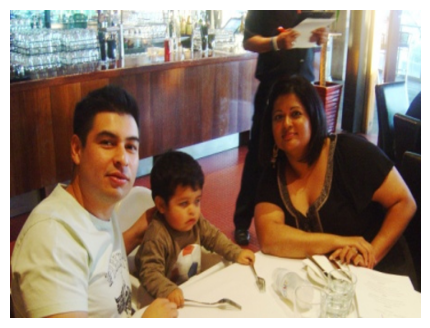

Generated Caption: a photo of people in a restaurant


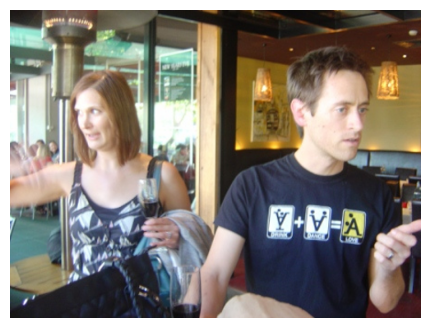

Generated Caption: a photo of people in a restaurant


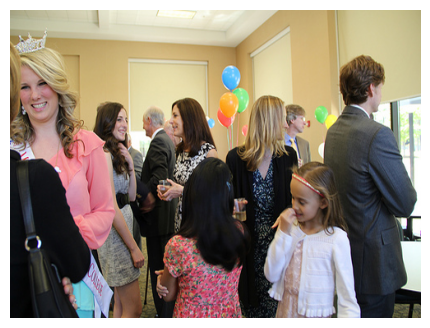

Generated Caption: a photo of people in a room


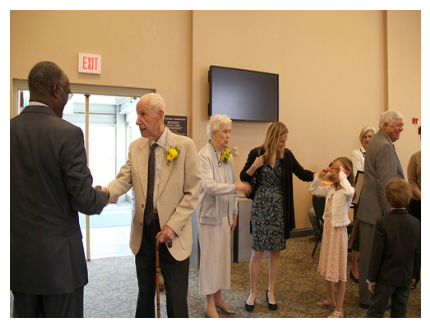

Generated Caption: a photo of people in a room


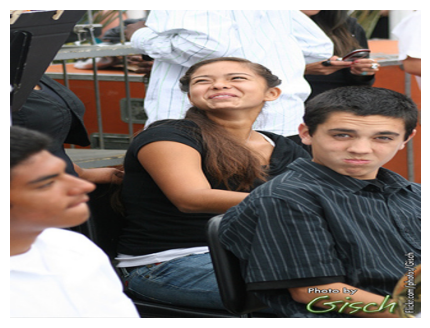

Generated Caption: a photo of people in a crowd


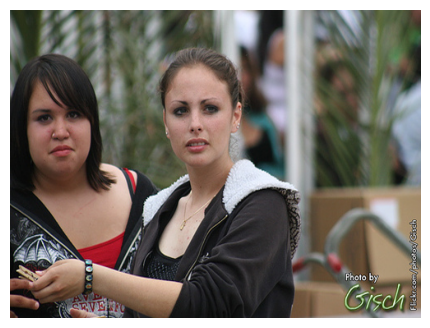

Generated Caption: a photo of people in a city


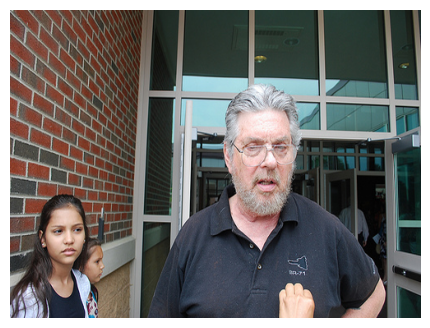

Generated Caption: a photo of people in a building


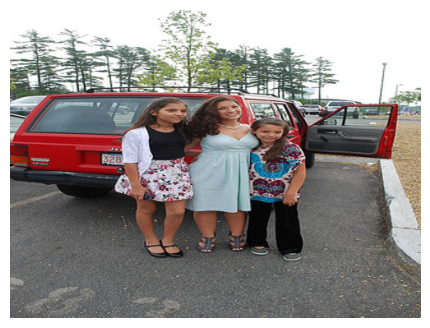

Generated Caption: a photo of people in a parking


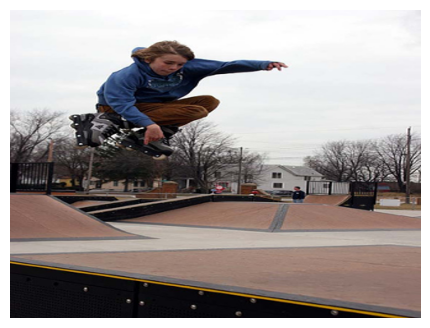

Generated Caption: a photo of people in a skate park


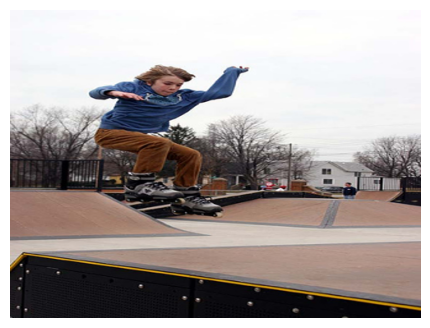

Generated Caption: a photo of people in a skate park


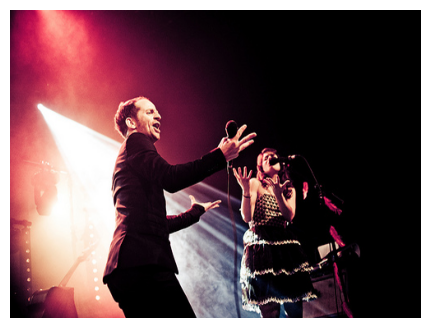

Generated Caption: a photo of people in a concert


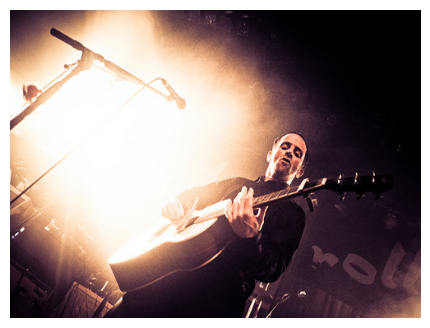

Generated Caption: a photo of people in a concert


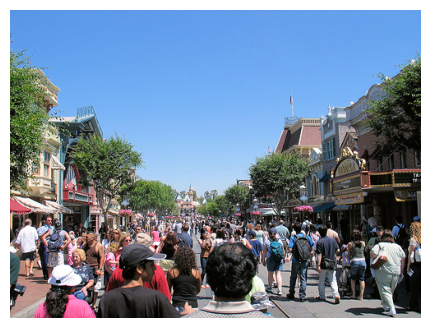

Generated Caption: a photo of people in a city


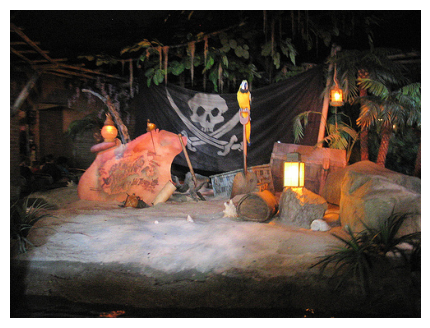

Generated Caption: a photo of people in a jungle setting


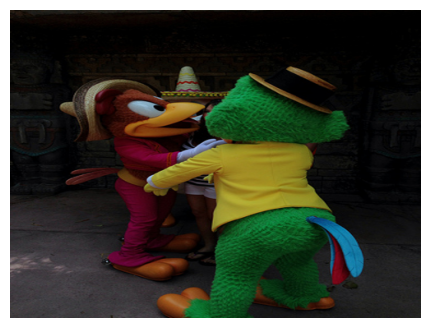

Generated Caption: a photo of people in a park


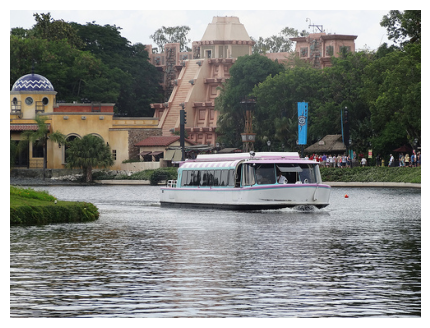

Generated Caption: a photo of people in a boat


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def generate_caption(img):
    """Generates a caption for an image using BLIP."""
    text_prompt = "A photo of people in a"
    inputs = processor(images=img, text=text_prompt, return_tensors="pt")
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_length=50)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return caption

def show_images_separately(root_folder, image_size=(500, 375), num_samples=5):
    """Displays images one at a time with captions separately."""
    
    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            images = [file for file in os.listdir(subfolder_path) if file.lower().endswith(('png', 'jpg', 'jpeg'))]
            sampled_images = np.random.choice(images, min(num_samples, len(images)), replace=False)
            
            for image_file in sampled_images:
                file_path = os.path.join(subfolder_path, image_file)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert("RGB")
                        img = img.resize(image_size)
                        caption = generate_caption(img)
                        
                        # Display image
                        plt.figure(figsize=(6, 4))
                        plt.imshow(img)
                        plt.axis("off")
                        plt.show()
                        
                        # Display caption separately
                        print("Generated Caption:", caption)
                        
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

# Example usage
root_folder = "./Albums"
show_images_separately(root_folder, image_size=(500, 375), num_samples=2)


## Labeling an album using different Captions


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import spacy
from collections import Counter
from transformers import BlipProcessor, BlipForConditionalGeneration

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# Initialize BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def generate_caption(img):
    """Generates a caption describing the type of event in the image."""
    text_prompt = "this event is called a"
    inputs = processor(images=img, text=text_prompt, return_tensors="pt")
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_length=50)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Remove the prompt from the output if it appears
    clean_caption = caption.replace(text_prompt, "").strip()

    return clean_caption

def extract_key_phrases(captions):
    """Extracts the most common meaningful phrases from a list of captions."""
    processed_text = " ".join(captions)
    doc = nlp(processed_text)
    
    # Extract meaningful nouns and proper nouns
    keywords = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"] and not token.is_stop]
    
    # Get most common phrases
    common_phrases = Counter(keywords).most_common(3)
    return " ".join([word for word, _ in common_phrases])

def get_cluster_name(images):
    """Determines a cluster name based on captions extracted from images."""
    captions = [generate_caption(img) for img in images]
    return extract_key_phrases(captions)

def label_albums(root_folder, image_size=(500, 375), num_samples=5):
    """Labels each album based on the most common event type in its images."""
    album_labels = {}

    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            images = [file for file in os.listdir(subfolder_path) if file.lower().endswith(('png', 'jpg', 'jpeg'))]
            sampled_images = np.random.choice(images, min(num_samples, len(images)), replace=False)
            
            album_images = []
            for image_file in sampled_images:
                file_path = os.path.join(subfolder_path, image_file)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert("RGB")
                        img = img.resize(image_size)
                        album_images.append(img)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

            # Generate album label
            if album_images:
                album_label = get_cluster_name(album_images)
                album_labels[subfolder] = album_label
                print(f"Album '{subfolder}' labeled as: {album_label}")

    return album_labels

# Example usage
root_folder = "./Albums"
album_labels = label_albums(root_folder, image_size=(500, 375), num_samples=10)


Album 'Birthday' labeled as: party wine night
Album 'Birthday2' labeled as: celebration birthday conference
Album 'Graduation' labeled as: festival jazz graduation
Album 'Graduation 2' labeled as: car wedding day
Album 'Personal_sports' labeled as: skate park
Album 'Show' labeled as: night music rock
Album 'ThemePark' labeled as: carnival disneyland night
Album 'ThemePark 2' labeled as: fiesta race festival


## Smart Labeler + K means + Feature Extractor

Loading images...
Clustering with K-Means...
Clustering accuracy: 82.59%

Proposed Cluster Names:
Cluster 0: Proposed Name = 'walk', True Label = 'Birthday'
Cluster 1: Proposed Name = 'christmas party festival', True Label = 'Graduation 2'
Cluster 2: Proposed Name = 'parade walk disney', True Label = 'ThemePark'
Cluster 3: Proposed Name = 'skate park', True Label = 'Personal_sports'
Cluster 4: Proposed Name = 'rock concert', True Label = 'Show'
Cluster 5: Proposed Name = 'meeting', True Label = 'Birthday2'
Cluster 6: Proposed Name = 'disney world parade', True Label = 'ThemePark 2'
Cluster 7: Proposed Name = 'christmas party festival', True Label = 'Graduation 2'
Clusters saved to clusters.txt


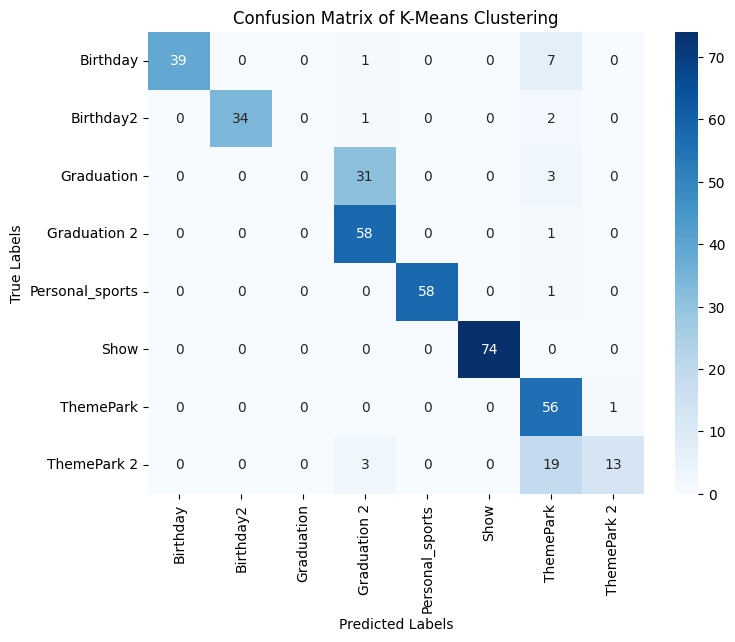

In [17]:
import spacy
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
import re

# Initialize BLIP processor and model for image captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Load spaCy English model for NLP processing
nlp = spacy.load("en_core_web_sm")

# Function to load images from subfolders and extract BLIP image embeddings
def load_images_from_folder_get_blip_image_embedding(root_folder, image_size=(500 , 375)):
    image_data = []  # Stores image feature vectors
    labels = []  # Stores corresponding numeric labels
    label_names = []  # Stores actual category names
    
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    with Image.open(file_path) as img:
                        img = img.convert("L")
                        img = img.resize(image_size)
                        
                        # Get BLIP image embedding
                        inputs = processor(images=img, return_tensors="pt")
                        pixel_values = inputs["pixel_values"]
                        with torch.no_grad():  
                            vision_outputs = model.vision_model(pixel_values=pixel_values)
                        image_embeds = vision_outputs.last_hidden_state[:, 0, :]

                        image_data.append(image_embeds.flatten().numpy())
                        labels.append(label)  

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names

# Function to generate captions for images
def generate_caption(img):
    """Generates a caption describing the type of event in the image."""
    text_prompt = "this event is called a"
    inputs = processor(images=img, text=text_prompt, return_tensors="pt")
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_length=50)
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Remove the prompt from the output if it appears
    clean_caption = caption.replace(text_prompt, "").strip()

    return clean_caption

def extract_key_phrases(captions):
    """Extracts the most common meaningful phrases from a list of captions."""
    processed_text = " ".join(captions)
    doc = nlp(processed_text)
    
    # Extract meaningful nouns and proper nouns
    keywords = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"] and not token.is_stop]
    
    # Get most common phrases
    common_phrases = Counter(keywords).most_common(3)
    return " ".join([word for word, _ in common_phrases])

def get_cluster_name(images):
    """Determines a cluster name based on captions extracted from images."""
    captions = [generate_caption(img) for img in images]
    return extract_key_phrases(captions)


# Function to perform clustering and evaluate accuracy
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder_get_blip_image_embedding(root_folder, image_size)
    
    print("Clustering with K-Means...")
    kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    cluster_proposed_names = {}
    
    for cluster in range(len(label_names)):
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
        
        if len(true_labels_in_cluster) > 0:
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label
            
            # Select a subset of images to caption for cluster naming
            sample_indices = np.random.choice(cluster_indices, min( 10 , len(cluster_indices)), replace=False)
            sample_images = [Image.open(os.path.join(root_folder, label_names[y_true[idx]], os.listdir(os.path.join(root_folder, label_names[y_true[idx]]))[0])) for idx in sample_indices]
            cluster_proposed_names[cluster] = get_cluster_name(sample_images)

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

    # Calculate clustering accuracy
    accuracy = accuracy_score(y_true, y_pred_mapped)
    print(f"Clustering accuracy: {accuracy:.2%}")

    # Display proposed names for each cluster
    print("\nProposed Cluster Names:")
    for cluster, name in cluster_proposed_names.items():
        print(f"Cluster {cluster}: Proposed Name = '{name}', True Label = '{label_names[cluster_to_label[cluster]]}'")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true]})\n")
        print("Clusters saved to clusters.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true, y_pred_mapped, label_names)
    
    return kmeans, accuracy

# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of K-Means Clustering")
    plt.show()

# Example usage
root_folder = "./Albums"
kmeans_model, acc = cluster_images(root_folder, image_size=(500 , 375), save_txt=True)
